# 01 — Data Harmonization to Unified Dataset
### European Used Car Prices (2023–2025) · AutoScout24

**Goal:** Load 2023/2024/2025 yearly CSVs with different schemas, harmonize column names,
normalize currencies/fuel types/body types, and produce a single clean parquet file.

**Pipeline:**
1. Load each year with correct delimiter and schema mapping
2. Rename columns to canonical names via `config.SCHEMA_MAP`
3. Year-specific fixes (2023: price/10, kW→HP, model first token; 2025: mileage_km_raw, registration_date→production_year, power_kw→power_hp)
4. Concatenate into unified DataFrame
5. Harmonize fuel_type, body_type, transmission, condition, country_code
6. Numeric cleaning (mileage 0–500K, power 10–2000, age >= 0)
7. Price filter (€800–€300K, per-year 1%/99% tails)
8. Remove non-European countries
9. Deduplication
10. Log-price target
11. Summary stats & quality visualization
12. Save to unified_dataset.parquet + materials.parquet

> **Note:** 2021/2022 data was dropped due to incompatible schemas and different population characteristics (such as PLN to EUR).

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import (
    FILE_MAP, CSV_DELIMITERS, SCHEMA_MAP, MATERIALS_FILE,
    PRICE_MIN_EUR, PRICE_MAX_EUR, AVG_FX_TO_EUR,
    COUNTRY_TO_ISO2, FUEL_HARMONIZE, BODY_HARMONIZE,
    TRANSMISSION_HARMONIZE, CONDITION_HARMONIZE,
    EV_FUELS, PHEV_FUELS, ICE_FUELS, get_powertrain,
    DATA_PROC, DATA_YEARS, FIGURES, NEUTRAL_COLORS,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 130

print('Setup complete.')
print(f'Data years to process: {DATA_YEARS}')

Setup complete.
Data years to process: [2023, 2024, 2025]


## 1. Load Raw CSVs (2023 / 2024 / 2025)

In [2]:
raw_frames = {}

for year in DATA_YEARS:
    path = FILE_MAP[year]
    sep = CSV_DELIMITERS[year]
    df_raw = pd.read_csv(path, sep=sep, low_memory=False, on_bad_lines='skip')
    raw_frames[year] = df_raw
    print(f'{year}: {df_raw.shape[0]:>8,} rows x {df_raw.shape[1]:>3} cols  |  '
          f'Columns: {list(df_raw.columns)[:8]}...')

total = sum(d.shape[0] for d in raw_frames.values())
print(f'\nTotal raw records (3 years): {total:,}')

2023:  100,659 rows x  24 cols  |  Columns: ['Unnamed: 0', 'Brand', 'Price', 'Carrosserie', 'État', 'Portes', 'Kilométrage', 'Année']...
2024:   40,494 rows x  25 cols  |  Columns: ['Make', 'Model', 'Body', 'Mileage_km', 'Price', 'Year', 'Country', 'Condition']...
2025:  118,382 rows x  75 cols  |  Columns: ['id', 'description', 'ratings_average', 'ratings_count', 'ratings_recommend_percentage', 'price_currency', 'price', 'price_tax_deductible']...

Total raw records (3 years): 259,535


## 2. Schema Mapping via `config.SCHEMA_MAP`

In [3]:
# Show schema mapping for each year
for year in DATA_YEARS:
    mapping = SCHEMA_MAP[year]
    available = [k for k in mapping if k in raw_frames[year].columns]
    print(f'\n{year}: {len(available)}/{len(mapping)} mapped columns available')
    for k in available[:10]:
        print(f'  {k:40s} -> {mapping[k]}')
    if len(available) > 10:
        print(f'  ... and {len(available)-10} more')


2023: 19/19 mapped columns available
  Brand                                    -> make
  ModelC                                   -> model
  Price                                    -> price
  Carrosserie                              -> body_type
  État                                     -> condition
  Kilométrage                              -> mileage_km
  Année                                    -> production_year
  Puissance kW                             -> power_kw
  Transmission                             -> transmission
  Carburant                                -> fuel_type
  ... and 9 more

2024: 24/24 mapped columns available
  Make                                     -> make
  Model                                    -> model
  Price                                    -> price
  Body                                     -> body_type
  Condition                                -> condition
  Mileage_km                               -> mileage_km
  Year                     

## 3. Year-Specific Fixes & Harmonization

In [4]:
harmonized = []

for year in DATA_YEARS:
    df_raw = raw_frames[year]
    mapping = SCHEMA_MAP[year]

    # Keep only columns that exist in raw data and are in our mapping
    existing = {k: v for k, v in mapping.items() if k in df_raw.columns}
    df = df_raw[list(existing.keys())].rename(columns=existing).copy()
    df['data_year'] = year

    # ── 2023-specific fixes ─────────────────────────────────────────────
    if year == 2023:
        # Price has 10x scaling bug
        df['price'] = pd.to_numeric(df['price'], errors='coerce')
        median_p = df['price'].median()
        if median_p > 100_000:
            df['price'] = df['price'] / 10
            print(f'  2023: Applied price /10 correction (median was {median_p:,.0f})')

        # Power is in kW -> convert to HP (1 kW = 1.341 HP)
        if 'power_kw' in df.columns:
            df['power_hp'] = (pd.to_numeric(df['power_kw'], errors='coerce') * 1.341).round(0)

        # Model field contains full description -> extract first token
        if 'model' in df.columns:
            df['model_full'] = df['model']
            df['model'] = df['model'].astype(str).str.strip().str.split().str[0]

        # No currency column -> assume EUR
        if 'currency' not in df.columns:
            df['currency'] = 'EUR'

    # ── 2024-specific fixes ─────────────────────────────────────────────
    if year == 2024:
        if 'currency' not in df.columns:
            df['currency'] = 'EUR'

    # ── 2025-specific fixes ─────────────────────────────────────────────
    if year == 2025:
        # mileage_km_raw is already numeric via schema mapping -> mileage_km
        df['mileage_km'] = pd.to_numeric(df['mileage_km'], errors='coerce')

        # registration_date -> derive production_year if production_year missing
        if 'first_registration' in df.columns:
            reg_year = pd.to_datetime(df['first_registration'], errors='coerce').dt.year
            df['production_year'] = df['production_year'].fillna(reg_year)

        # power_kw -> power_hp (fill gaps)
        if 'power_kw' in df.columns:
            kw_hp = (pd.to_numeric(df['power_kw'], errors='coerce') * 1.341).round(0)
            df['power_hp'] = pd.to_numeric(df['power_hp'], errors='coerce').fillna(kw_hp)

    harmonized.append(df)
    print(f'{year}: {len(df):>8,} rows, {len(df.columns):>3} cols after harmonization')

print(f'\nReady to concatenate {len(harmonized)} frames.')

  2023: Applied price /10 correction (median was 346,901)
2023:  100,659 rows,  23 cols after harmonization
2024:   40,494 rows,  26 cols after harmonization
2025:  118,382 rows,  39 cols after harmonization

Ready to concatenate 3 frames.


## 4. Concatenate Into Unified DataFrame

In [5]:
from collections import Counter

col_counts = Counter()
for df in harmonized:
    col_counts.update(df.columns)

# Columns present in >= 2 out of 3 years
common_cols = sorted([c for c, n in col_counts.items() if n >= 2])
print(f'Columns in >= 2 years ({len(common_cols)}): {common_cols}')

# Concat (outer join — NaN for missing cols in some years)
df = pd.concat(harmonized, axis=0, ignore_index=True, sort=False)
print(f'\nUnified shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Years: {sorted(df["data_year"].unique())}')
print(f'\nRows per year:')
print(df['data_year'].value_counts().sort_index())

Columns in >= 2 years (26): ['body_type', 'color', 'condition', 'country_raw', 'currency', 'cylinders', 'data_year', 'doors', 'drivetrain', 'engine_cc', 'fuel_type', 'full_service_history', 'gears', 'make', 'mileage_km', 'model', 'non_smoker', 'nr_prev_owners', 'power_hp', 'power_kw', 'price', 'production_year', 'seats', 'seller_type', 'transmission', 'upholstery']

Unified shape: 259,535 rows x 47 cols
Years: [np.int64(2023), np.int64(2024), np.int64(2025)]

Rows per year:
data_year
2023    100659
2024     40494
2025    118382
Name: count, dtype: int64


## 5. Harmonize Categorical Columns

In [6]:
# ── Ensure price is numeric ──
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# ── Currency conversion to EUR ──
def convert_to_eur(row):
    price = row['price']
    curr = str(row.get('currency', 'EUR')).strip().upper()
    year = row['data_year']
    if pd.isna(price):
        return np.nan
    if curr in ('EUR', 'NAN', ''):
        return price
    fx_dict = AVG_FX_TO_EUR.get(curr)
    if fx_dict is None:
        return price
    rate = fx_dict.get(year, fx_dict.get(2025, 1.0))
    return price * rate

df['price_eur'] = df.apply(convert_to_eur, axis=1)
print('Currency distribution:')
print(df['currency'].value_counts())
print(f'\nPrice EUR: min={df["price_eur"].min():,.0f}, '
      f'median={df["price_eur"].median():,.0f}, '
      f'max={df["price_eur"].max():,.0f}')

Currency distribution:
currency
EUR    259535
Name: count, dtype: int64

Price EUR: min=1, median=34,300, max=13,500,000


In [7]:
# ── Make & Model ──
df['make'] = df['make'].astype(str).str.strip().str.title()
df['model'] = df['model'].astype(str).str.strip()

# ── Fuel type ──
df['fuel_type_raw'] = df['fuel_type'].copy()
df['fuel_type'] = (
    df['fuel_type'].astype(str).str.strip().str.lower()
    .map(FUEL_HARMONIZE).fillna('Other')
)
print('Fuel types after harmonization:')
print(df['fuel_type'].value_counts())

# ── Powertrain segment ──
df['powertrain'] = df['fuel_type'].apply(get_powertrain)
print(f'\nPowertrain segments:')
print(df['powertrain'].value_counts())

# ── Body type ──
df['body_type'] = (
    df['body_type'].astype(str).str.strip().str.lower()
    .map(BODY_HARMONIZE).fillna('Other')
)
print(f'\nBody types:')
print(df['body_type'].value_counts())

# ── Transmission ──
df['transmission'] = (
    df['transmission'].astype(str).str.strip().str.lower()
    .map(TRANSMISSION_HARMONIZE).fillna('Unknown')
)
print(f'\nTransmission:')
print(df['transmission'].value_counts())

# ── Condition ──
df['condition'] = (
    df['condition'].astype(str).str.strip().str.lower()
    .map(CONDITION_HARMONIZE).fillna('Used')
)
print(f'\nCondition:')
print(df['condition'].value_counts())

Fuel types after harmonization:
fuel_type
Gasoline         131913
Diesel            83562
Hybrid_PHEV       23665
Electric          13543
Hybrid_Diesel      3797
Other              1883
LPG                1026
CNG                 146
Name: count, dtype: int64

Powertrain segments:
powertrain
ICE      216647
PHEV      27462
EV        13543
Other      1883
Name: count, dtype: int64

Body types:
body_type
SUV            61497
Sedan          52200
Other          37858
Coupe          32146
Estate         30976
Convertible    18744
Van            13762
Hatchback      12352
Name: count, dtype: int64

Transmission:
transmission
Automatic         202283
Manual             49193
Semi-Automatic      6763
Unknown             1296
Name: count, dtype: int64

Condition:
condition
Used    248508
New      11027
Name: count, dtype: int64


In [8]:
# ── Country code normalization ──
df['country_code'] = (
    df['country_raw'].astype(str).str.strip().str.lower()
    .map(COUNTRY_TO_ISO2)
)

# For 2025, country_raw may already be ISO-2
mask_null = df['country_code'].isna()
df.loc[mask_null, 'country_code'] = (
    df.loc[mask_null, 'country_raw'].astype(str).str.strip().str.upper()
    .where(lambda s: s.str.len() == 2)
)

print('Country code distribution:')
print(df['country_code'].value_counts().head(15))
print(f'\nMissing country: {df["country_code"].isna().sum():,}')

Country code distribution:
country_code
DE    82432
IT    49078
NL    38303
BE    26420
FR    24324
AT    22974
ES     9872
LU     3525
Name: count, dtype: int64

Missing country: 2,607


## 6. Numeric Cleaning (Mileage 0–500K, Power 10–2000, Age >= 0)

In [9]:
# Force numeric types
numeric_cols = ['mileage_km', 'production_year', 'power_hp', 'engine_cc',
                'co2_emission', 'doors', 'seats', 'gears', 'nr_prev_owners',
                'electric_range_km', 'weight_kg']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Vehicle age ──
df['production_year'] = pd.to_numeric(df['production_year'], errors='coerce')
df['production_year'] = df['production_year'].clip(lower=1950, upper=2025)
df['vehicle_age'] = df['data_year'] - df['production_year']
df.loc[df['vehicle_age'] < 0, 'vehicle_age'] = np.nan

# ── Mileage: 0–500K ──
df.loc[df['mileage_km'] < 0, 'mileage_km'] = np.nan
df.loc[df['mileage_km'] > 500_000, 'mileage_km'] = np.nan

# ── Power: 10–2000 HP ──
df.loc[df['power_hp'] < 10, 'power_hp'] = np.nan
df.loc[df['power_hp'] > 2000, 'power_hp'] = np.nan

# ── Engine cc ──
if 'engine_cc' in df.columns:
    df.loc[df['engine_cc'] < 50, 'engine_cc'] = np.nan
    df.loc[df['engine_cc'] > 10000, 'engine_cc'] = np.nan

print('Numeric column summary after cleaning:')
print(df[['price_eur', 'mileage_km', 'production_year', 'power_hp',
           'vehicle_age']].describe().round(1))

Numeric column summary after cleaning:
        price_eur  mileage_km  production_year  power_hp  vehicle_age
count    259535.0    258846.0         257684.0  257365.0     253135.0
mean      52704.6     62674.1           2018.3     268.5          5.9
std      108002.9     67857.7              7.9     150.2          7.8
min           1.0         0.0           1950.0      10.0          0.0
25%       14260.0      9470.2           2017.0     150.0          1.0
50%       34300.0     39800.0           2020.0     218.0          4.0
75%       67000.0     97000.0           2022.0     360.0          7.0
max    13500000.0    500000.0           2025.0    1613.0         75.0


## 7. Price Filter (EUR 800–300K, Per-Year 1%/99% Tails)

In [10]:
n_before = len(df)

# Remove rows with no price
df = df[df['price_eur'].notna()].copy()
print(f'Removed {n_before - len(df):,} rows with missing price')

# Apply absolute price bounds
n_before = len(df)
df = df[(df['price_eur'] >= PRICE_MIN_EUR) & (df['price_eur'] <= PRICE_MAX_EUR)].copy()
print(f'Removed {n_before - len(df):,} rows outside EUR {PRICE_MIN_EUR:,}–{PRICE_MAX_EUR:,}')

# Remove per-year 1%/99% tails
n_before = len(df)
keep_mask = pd.Series(True, index=df.index)
for year in df['data_year'].unique():
    yr_mask = df['data_year'] == year
    p01 = df.loc[yr_mask, 'price_eur'].quantile(0.01)
    p99 = df.loc[yr_mask, 'price_eur'].quantile(0.99)
    keep_mask &= ~(yr_mask & ((df['price_eur'] < p01) | (df['price_eur'] > p99)))
    print(f'  {year}: 1% = EUR {p01:,.0f}, 99% = EUR {p99:,.0f}')
df = df[keep_mask].copy()
print(f'Removed {n_before - len(df):,} rows in per-year 1%/99% tails')

print(f'\nFinal price range: EUR {df["price_eur"].min():,.0f} – {df["price_eur"].max():,.0f}')
print(f'Remaining rows: {len(df):,}')

Removed 0 rows with missing price
Removed 7,975 rows outside EUR 800–300,000
  2023: 1% = EUR 1,100, 99% = EUR 225,500
  2024: 1% = EUR 1,900, 99% = EUR 265,000
  2025: 1% = EUR 2,250, 99% = EUR 222,000
Removed 4,997 rows in per-year 1%/99% tails

Final price range: EUR 1,100 – 265,000
Remaining rows: 246,563


## 8. Remove Non-European Countries

In [11]:
EUROPEAN_ISO2 = {
    'DE', 'FR', 'IT', 'ES', 'NL', 'BE', 'AT', 'CH', 'SE', 'DK',
    'NO', 'FI', 'PL', 'CZ', 'SK', 'HU', 'RO', 'BG', 'HR', 'SI',
    'IE', 'PT', 'GR', 'LU', 'GB',
}

n_before = len(df)
# Also drop rows with missing country
non_eu_mask = (~df['country_code'].isin(EUROPEAN_ISO2)) | df['country_code'].isna()
removed = df[non_eu_mask]['country_code'].value_counts(dropna=False)
print('Removing non-European / missing country rows:')
print(removed)

df = df[df['country_code'].isin(EUROPEAN_ISO2)].copy()
print(f'\nRemoved {n_before - len(df):,} non-European rows')
print(f'Remaining rows: {len(df):,}')
print(f'\nCountry distribution after filter:')
print(df['country_code'].value_counts())

Removing non-European / missing country rows:
country_code
NaN    2387
Name: count, dtype: int64

Removed 2,387 non-European rows
Remaining rows: 244,176

Country distribution after filter:
country_code
DE    79773
IT    47181
NL    36697
BE    25418
FR    21687
AT    20521
ES     9529
LU     3370
Name: count, dtype: int64


## 9. Deduplication

In [12]:
dedup_cols = ['make', 'model', 'price_eur', 'mileage_km', 'production_year',
              'power_hp', 'fuel_type', 'country_code', 'data_year']
dedup_existing = [c for c in dedup_cols if c in df.columns]

n_before = len(df)
df = df.drop_duplicates(subset=dedup_existing, keep='first').reset_index(drop=True)
print(f'Removed {n_before - len(df):,} duplicate rows')
print(f'Final dataset: {len(df):,} rows')

Removed 15,306 duplicate rows
Final dataset: 228,870 rows


## 10. Log-Price Target

In [13]:
df['log_price'] = np.log1p(df['price_eur'])

print(f'log_price stats:')
print(f'  mean:  {df["log_price"].mean():.4f}')
print(f'  std:   {df["log_price"].std():.4f}')
print(f'  range: [{df["log_price"].min():.2f}, {df["log_price"].max():.2f}]')

log_price stats:
  mean:  10.2737
  std:   1.1013
  range: [7.00, 12.49]


## 11. Summary Statistics & Quality Visualization

In [14]:
print('=' * 80)
print('UNIFIED DATASET — SUMMARY')
print('=' * 80)

print(f'\nShape: {df.shape}')
print(f'\n--- Rows per year ---')
print(df['data_year'].value_counts().sort_index())

print(f'\n--- Powertrain per year ---')
print(pd.crosstab(df['data_year'], df['powertrain'], margins=True))

print(f'\n--- Country per year (top 5 overall) ---')
top5c = df['country_code'].value_counts().head(5).index
print(pd.crosstab(df['data_year'], df['country_code'])[top5c])

print(f'\n--- Price EUR by year ---')
print(df.groupby('data_year')['price_eur'].agg(['count', 'mean', 'median', 'std']).round(0))

print(f'\n--- Missing values (top 15) ---')
miss = df.isnull().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(1)
print(pd.DataFrame({'missing': miss.head(15), 'pct': miss_pct.head(15)}))

UNIFIED DATASET — SUMMARY

Shape: (228870, 53)

--- Rows per year ---
data_year
2023     86060
2024     34964
2025    107846
Name: count, dtype: int64

--- Powertrain per year ---
powertrain     EV     ICE  Other   PHEV     All
data_year                                      
2023         2372   82306   1382      0   86060
2024         2954   26277     85   5648   34964
2025         6740   81687    335  19084  107846
All         12066  190270   1802  24732  228870

--- Country per year (top 5 overall) ---
country_code     DE     IT     NL     BE     FR
data_year                                      
2023          20033  10261  15408  12048  14218
2024          14275   9113   3881   3635   1155
2025          41937  22190  14981   9000   5879

--- Price EUR by year ---
            count     mean   median      std
data_year                                   
2023        86060  45242.0  37750.0  44555.0
2024        34964  34394.0  21595.0  42615.0
2025       107846  52251.0  39490.0  40625.

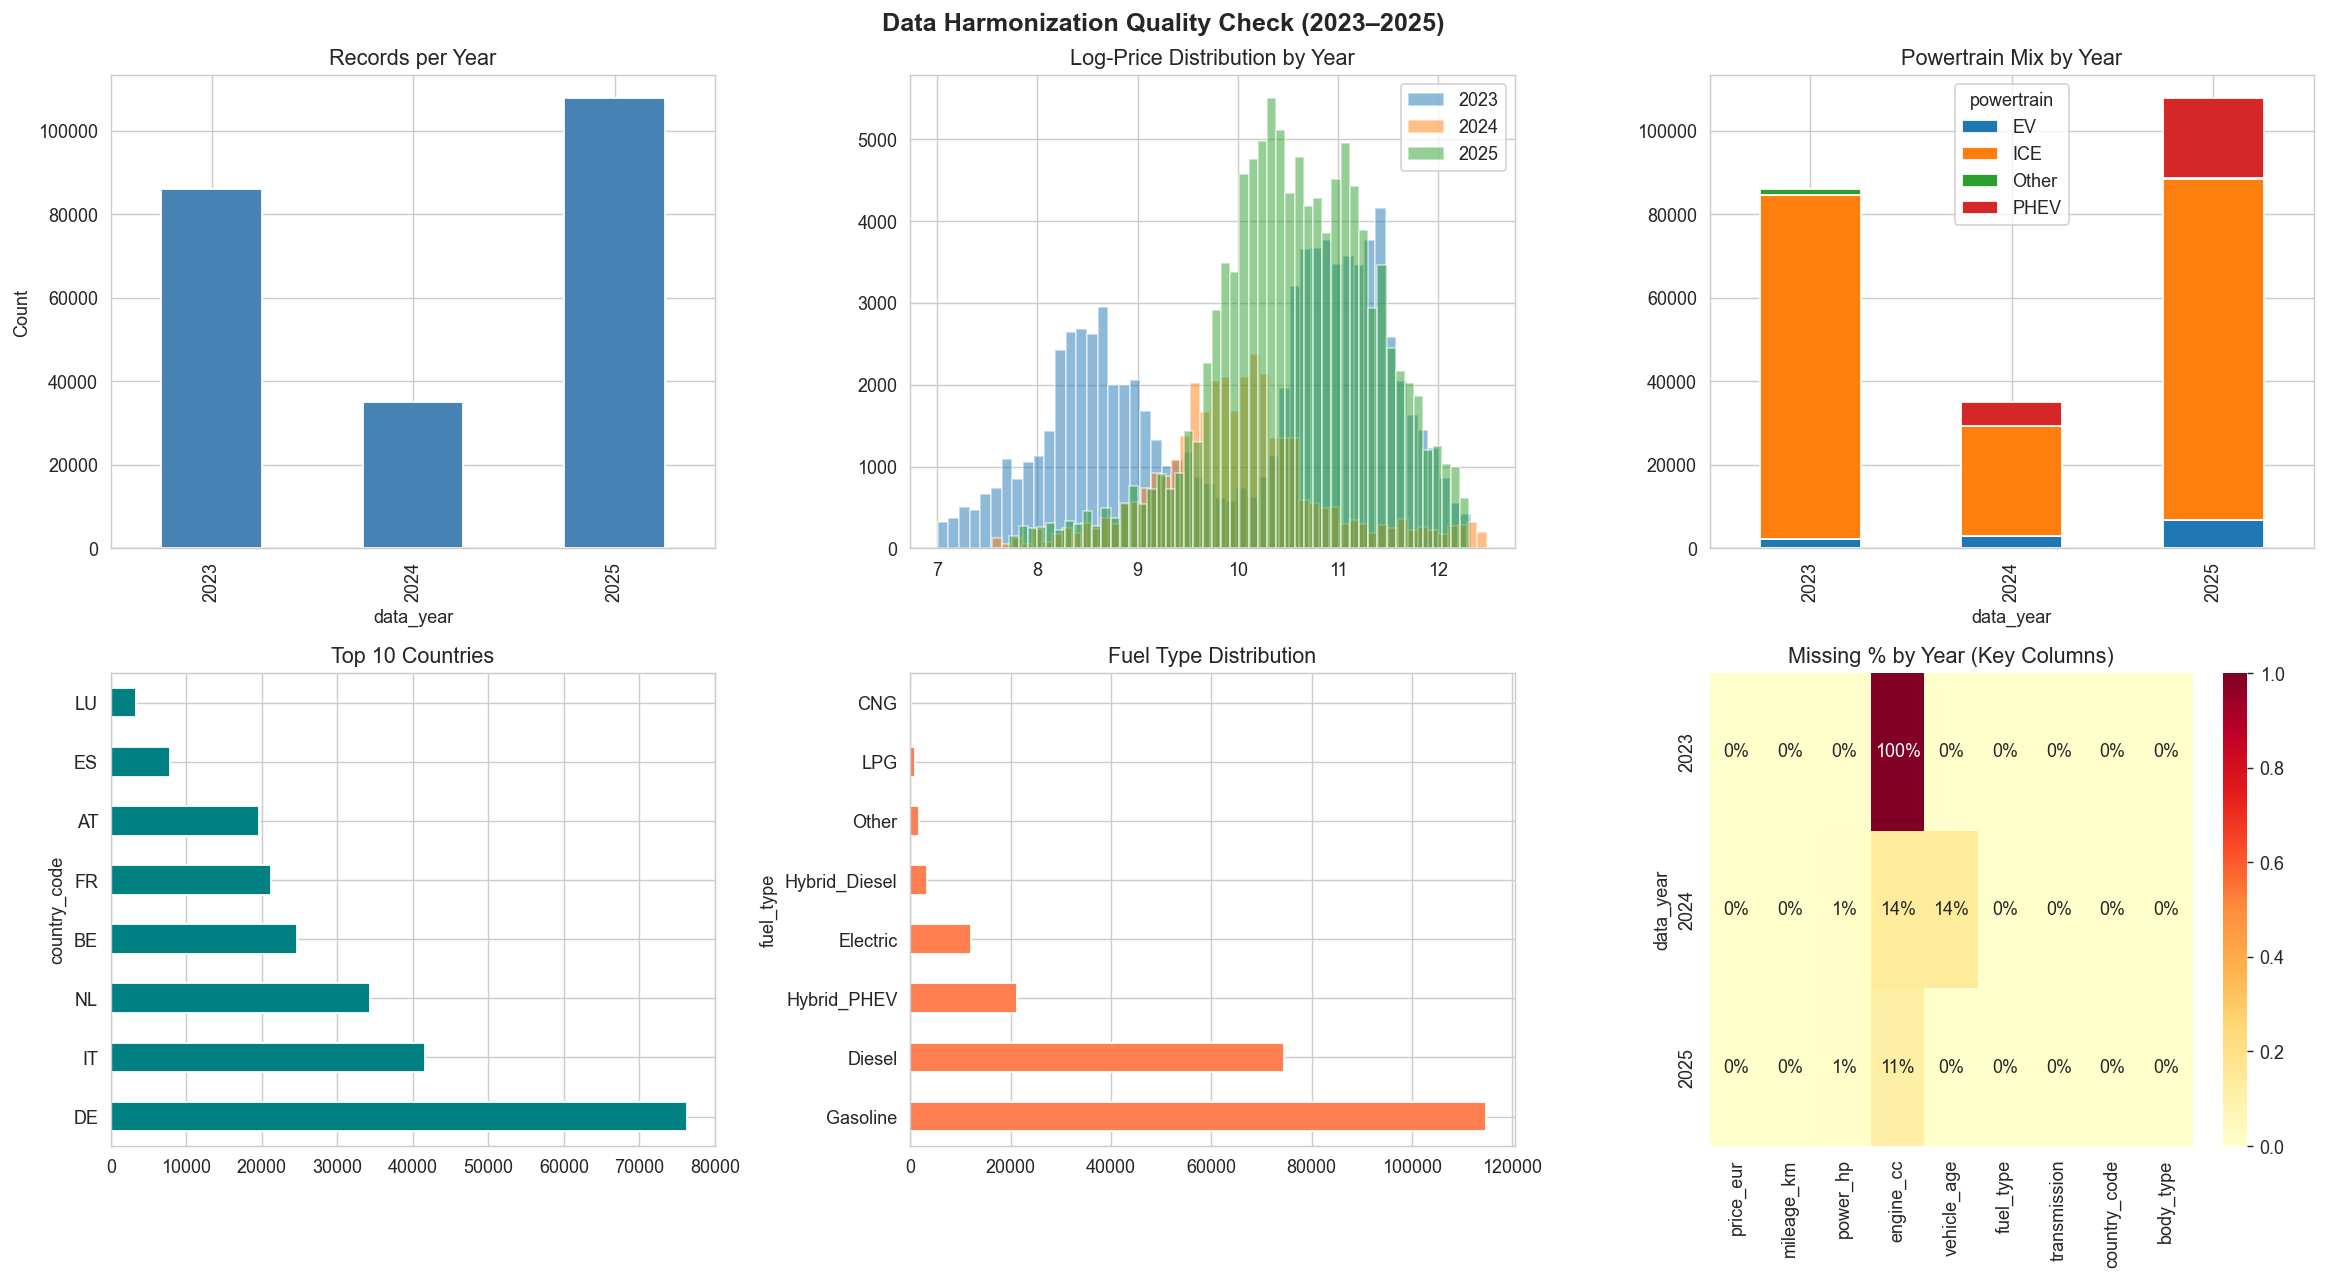

Figure saved.


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Data Harmonization Quality Check (2023–2025)', fontsize=14, fontweight='bold')

# 1. Records per year
df['data_year'].value_counts().sort_index().plot.bar(ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Records per Year')
axes[0, 0].set_ylabel('Count')

# 2. Price distribution per year
for year in sorted(df['data_year'].unique()):
    axes[0, 1].hist(df.loc[df['data_year'] == year, 'log_price'],
                    bins=50, alpha=0.5, label=str(year))
axes[0, 1].set_title('Log-Price Distribution by Year')
axes[0, 1].legend()

# 3. Powertrain per year
pd.crosstab(df['data_year'], df['powertrain']).plot.bar(stacked=True, ax=axes[0, 2])
axes[0, 2].set_title('Powertrain Mix by Year')

# 4. Top 10 countries
df['country_code'].value_counts().head(10).plot.barh(ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Top 10 Countries')

# 5. Fuel type distribution
df['fuel_type'].value_counts().head(8).plot.barh(ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Fuel Type Distribution')

# 6. Missing values heatmap by year
key_cols = ['price_eur', 'mileage_km', 'power_hp', 'engine_cc', 'vehicle_age',
            'fuel_type', 'transmission', 'country_code', 'body_type']
miss_by_year = df.groupby('data_year')[key_cols].apply(lambda x: x.isna().mean()).round(2)
sns.heatmap(miss_by_year, annot=True, cmap='YlOrRd', ax=axes[1, 2], fmt='.0%')
axes[1, 2].set_title('Missing % by Year (Key Columns)')

plt.tight_layout()
plt.savefig(FIGURES / '01_harmonization_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 12. Save to unified_dataset.parquet + materials.parquet

In [16]:
# Cast object columns to string for parquet compatibility
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)

out_path = DATA_PROC / 'unified_dataset.parquet'
df.to_parquet(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Size: {out_path.stat().st_size / 1e6:.1f} MB')
print(f'Shape: {df.shape}')

# Save materials data as parquet
mat = pd.read_csv(MATERIALS_FILE)
mat.to_parquet(DATA_PROC / 'materials.parquet', index=False)
print(f'\nMaterials saved: {DATA_PROC / "materials.parquet"}')
print(mat.head())

print('\n' + '=' * 80)
print('DATA HARMONIZATION COMPLETE')
print('=' * 80)

Saved: /Users/elbekmajidov/Developer/Master's in Data Science/University of Warsaw/master-thesis-9/notebooks/../data/processed/unified_dataset.parquet
Size: 20.0 MB
Shape: (228870, 53)

Materials saved: /Users/elbekmajidov/Developer/Master's in Data Science/University of Warsaw/master-thesis-9/notebooks/../data/processed/materials.parquet
         date material  price_usd_per_ton
0  2021-01-01  Lithium              15000
1  2021-12-31  Lithium              50000
2  2022-01-01  Lithium              55000
3  2022-12-31  Lithium              45000
4  2023-01-01  Lithium              40000

DATA HARMONIZATION COMPLETE
